In [69]:
# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

---
## 1. Data Collection / Preparation


We first start off by pulling the API from Skinport.com, where the original file was given to us in `skinport_items.json`. We convert over to `skinport_items.csv`, for easier handling. Print the first few rows to see what columns we are working with, and select only useful data

---

In [70]:
# JSON taken from saving https://api.skinport.com/v1/sales/history?currency=USD

df = pd.read_json('data/skinport_items.json')
df.to_csv('data/skinport_items.csv', index=False)

# Identify the columns we want to keep
print(df.head())
print(df.columns) 




                             market_hash_name version currency  \
0  Sticker Slab | BIG (Gold) | Stockholm 2021     NaN      USD   
1  Sticker Slab | Kvik (Foil) | Katowice 2019     NaN      USD   
2         Sticker Slab | B1ad3 | Cologne 2015     NaN      USD   
3                   Sticker Slab | Pocket BBQ     NaN      USD   
4          Sticker Slab | oSee | Antwerp 2022     NaN      USD   

                                           item_page  \
0  https://skinport.com/item/sticker-slab-big-gol...   
1  https://skinport.com/item/sticker-slab-kvik-fo...   
2  https://skinport.com/item/sticker-slab-b1ad3-c...   
3  https://skinport.com/item/sticker-slab-pocket-bbq   
4  https://skinport.com/item/sticker-slab-osee-an...   

                                         market_page  \
0  https://skinport.com/market?item=BIG%20(Gold)%...   
1  https://skinport.com/market?item=Kvik%20(Foil)...   
2  https://skinport.com/market?item=B1ad3%20%7C%2...   
3  https://skinport.com/market?item=Pocket

---

# 1.1 Selecting Columns 

From the list of columns we have a total of 9 columns, `'market_hash_name', 'version', 'currency', 'item_page', 'market_page', 'last_24_hours', 'last_7_days', 'last_30_days', 'last_90_days'`. From, an initial glance, we can see that `'item_page'` and `'market_page'` are columns that link to a specific items store page, since we are interested in doing analysis on quantifiable data, we can drop those two columns. We are also only interested in the data of weapon skins for the past month (30 day), so we can drop all other time variables.

---

In [71]:
#Creating a temporary cleaned data frame with only columns we want to keep for analysis
df_cleaned_temp = df.drop(columns=[
    "item_page",
    "market_page",
    "last_24_hours",
    "last_7_days",
    "last_90_days"
])

print(df_cleaned_temp.shape)
df_cleaned_temp.head()

(33855, 4)


,market_hash_name,version,currency,last_30_days
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
3,Sticker Slab | Pocket BBQ,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,"{'min': None, 'max': None, 'avg': None, 'media..."


---

Notice that `'last_30_days'` is a dictionary containing `'min'`, `'max'`, `'avg'`, `'median'`, `'volume'`. We can extract this out into columns for our cleaned data frame.

---

In [72]:
last_30_days = pd.json_normalize(df['last_30_days']) # expand the dictionary of last_30_days into a temporary data frame

df_cleaned_temp = df_cleaned_temp.join(last_30_days)
df_cleaned_temp = df_cleaned_temp.drop(columns='last_30_days')

df_cleaned_temp.head()

,market_hash_name,version,currency,min,max,avg,median,volume
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,USD,NaN,NaN,NaN,NaN,0
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,USD,NaN,NaN,NaN,NaN,0
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,USD,NaN,NaN,NaN,NaN,0
3,Sticker Slab | Pocket BBQ,NaN,USD,NaN,NaN,NaN,NaN,0
4,Sticker Slab | oSee | Antwerp 2022,NaN,USD,NaN,NaN,NaN,NaN,0


---

Next check for missing data 

---

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    32889        97.146655
currency                       0         0.000000
min                        16205        47.865899
max                        16205        47.865899
avg                        16205        47.865899
median                     16205        47.865899
volume                         0         0.000000


<Axes: >

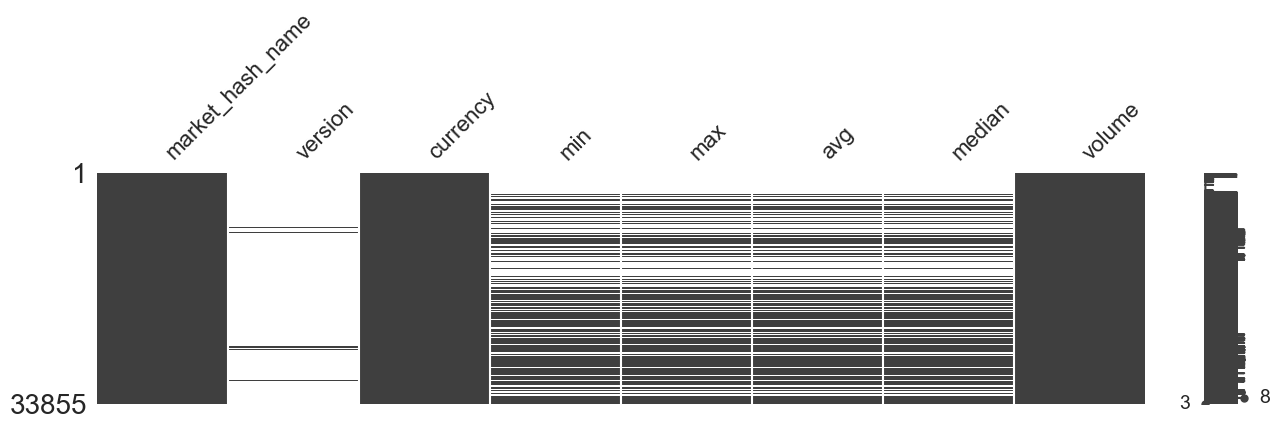

In [73]:
missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(missing_table)


# We can visualize the missing data with missingno
msno.matrix(df_cleaned_temp, figsize=(15, 3)) 

---

Note: All the missing data seems to be all from the same entries, so we will remove rows where every statistic is missing

---

In [74]:
# Remove rows where every statistic is missing
df_cleaned_temp = df_cleaned_temp.dropna(subset=["min", "max", "avg", "median"], how="all") # version is not dropped as None *is* a valid version rather than representing null

new_missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(new_missing_table)
print(df_cleaned_temp.shape) # removed exactly 16205 entires, as expected
df_cleaned_temp.head()

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
version                    17251        97.739377
currency                       0         0.000000
min                            0         0.000000
max                            0         0.000000
avg                            0         0.000000
median                         0         0.000000
volume                         0         0.000000
(17650, 8)


,market_hash_name,version,currency,min,max,avg,median,volume
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7
332,Souvenir XM1014 | Hieroglyph (Factory New),NaN,USD,0.56,1.20,0.99,1.04,6
343,Souvenir MAG-7 | Copper Coated (Field-Tested),NaN,USD,0.35,1.16,0.59,0.44,4
580,Souvenir P90 | ScaraB Rush (Well-Worn),NaN,USD,4.92,4.92,4.92,4.92,1
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1


---

From `'market_hash_name'` we get a lot of information regarding a specific skin that can affect it's pricing, such as `Souvenir` status,  `StatTrak™` status, `skin names` and item `condition`. We can break `market_hash_name` into seperate categorical variables. 

We also want to look at the most common used weapons in the game, as those weapons have more "value" due to popularity, so we filter by those weapons, which would include the `AK-47`, `M4A1-S`, `M4A4`, and `AWP`.

---

In [75]:
# create new columns souvenir and stat_trak

df_cleaned_temp["souvenir"] = df_cleaned_temp["market_hash_name"].str.contains("Souvenir")
df_cleaned_temp["stat_trak"] = df_cleaned_temp["market_hash_name"].str.contains("StatTrak")

#filtering 4 most popular guns for analysis

temp_df = df_cleaned_temp[df_cleaned_temp["market_hash_name"].str.contains("AK-47|M4A1-S|M4A4|AWP")]

temp_df.head()
df_cleaned = temp_df
df_cleaned.head()

,market_hash_name,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,Souvenir AK-47 | Steel Delta (Field-Tested),NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47 | Black Laminate (Well-Worn),NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47 | Aquamarine Revenge (Battle-Scarred),NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47 | Fire Serpent (Factory New),NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47 | Predator (Battle-Scarred),NaN,USD,9.23,9.68,9.46,9.45,2,False,False


---

We can now break apart `'market_has_name'` into seperate variables (`weapon`, `skin_name`, `condition`).

---

In [76]:
# seperate market hash name into different variables
df_cleaned[['weapon', 'skin_name', 'condition']] = df_cleaned['market_hash_name'].str.extract(r'(.+?)\s*\|\s*(.+?)\s*\((.+?)\)', expand=True)

# embellishments (souvenir, stattrak) are unecessary to remove because we will filter weapon types through .contains() anyways

df_cleaned=df_cleaned.drop(columns='market_hash_name')
df_cleaned.head()

,version,currency,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin_name,condition
210,NaN,USD,4.06,8.61,5.35,4.87,7,True,False,Souvenir AK-47,Steel Delta,Field-Tested
2795,NaN,USD,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,Well-Worn
2813,NaN,USD,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,Battle-Scarred
2814,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,Factory New
2908,NaN,USD,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,Battle-Scarred


---

Reorder Columns for better readability.

---

In [77]:
# Remove souvenir / StatTrak from weapon names since we already have tuples categories
df_cleaned['weapon'] = df_cleaned['weapon'].str.replace(
    r"(Souvenir\s+|StatTrak™?\s+)",
    "",
    regex=True
).str.strip()

#Reordering columns for better readability
first_cols = ["weapon", "skin_name", "condition"]
other_cols = [col for col in df_cleaned.columns if col not in first_cols]

df_cleaned = df_cleaned[first_cols + other_cols]

df_cleaned.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,Field-Tested,NaN,USD,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47,Black Laminate,Well-Worn,NaN,USD,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47,Aquamarine Revenge,Battle-Scarred,NaN,USD,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47,Fire Serpent,Factory New,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47,Predator,Battle-Scarred,NaN,USD,9.23,9.68,9.46,9.45,2,False,False


---

For analysis we typically want quantifiable variables and numeric values. In Counter-Strike 2, weapon conditions can affect a skins price, so we can assign corresponding condition values to every possible weapon condition. Since we are converting character values into numeric variables, we might as well convert our boolean variables `'souvenir'` and `'stat_trak'` into binary values for easier analysis as well.

---

In [78]:
# Convert souvenir and stat_trak boolean status to binary for regression purposes
df_cleaned["souvenir"] = df_cleaned["souvenir"].astype(int)
df_cleaned["stat_trak"] = df_cleaned["stat_trak"].astype(int)


# map values to condition for linear regression purposes
condition_codes = {
    "Factory New": 4, 
    "Minimal Wear": 3, 
    "Field-Tested": 2,
    "Well-Worn": 1, 
    "Battle-Scarred": 0,
}

# recode age categories
df_cleaned_enc = df_cleaned.replace({'condition': condition_codes})

df = df_cleaned_enc

df.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0


---

Finally, we drop rows whose `'condition'` isn't one of our five wear tiers. These are items whose parenthetical wasn't a wear tier usually due to special characters (e.g. `'M4A4 | 龍王 (Dragon King)'`), plus stickers/graffiti and unparsed rows that slipped through the weapon filter.

---

In [79]:
print("Before:", df.shape)

# keep only rows where condition is one of our 5 wear tiers (0-4)
df = df[df["condition"].isin([0, 1, 2, 3, 4])]
df["condition"] = df["condition"].astype(int)

print("After: ", df.shape)
print(df["weapon"].value_counts())   # sanity check: should be just the 4 weapons
df.head()


Before: (1469, 12)
After:  (1445, 12)
weapon
AK-47     455
AWP       339
M4A4      337
M4A1-S    314
Name: count, dtype: int64


,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0


---

Now we have the completed cleaned our data for analysis, we can convert it into a csv file(`skinport_items_cleaned(1).csv`) for others to use.

---

In [80]:
# write to csv for others to use

df.to_csv('data/skinport_items_cleaned(1).csv', index=False)

In [81]:
df["price_tier"] = pd.qcut(
    df["avg"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

df.head()

,weapon,skin_name,condition,version,currency,min,max,avg,median,volume,souvenir,stat_trak,price_tier
210,AK-47,Steel Delta,2,NaN,USD,4.06,8.61,5.35,4.87,7,1,0,Low
2795,AK-47,Black Laminate,1,NaN,USD,58.03,58.03,58.03,58.03,1,0,0,Medium-High
2813,AK-47,Aquamarine Revenge,0,NaN,USD,27.33,35.98,32.02,31.67,7,0,0,Medium-Low
2814,AK-47,Fire Serpent,4,NaN,USD,2485.40,2625.52,2555.46,2555.46,2,0,0,High
2908,AK-47,Predator,0,NaN,USD,9.23,9.68,9.46,9.45,2,0,0,Medium-Low


---

## 2. Data Visualization 

With the cleaned data frame, we can now look into visualizing the data for each of our weapon.

---

For a quick intial look into our data, we take a look into the counts of the weapons, and remove any unwanted columns

In [82]:
df['weapon'].value_counts()

weapon
AK-47     455
AWP       339
M4A4      337
M4A1-S    314
Name: count, dtype: int64

## 2.1 Histograms

---

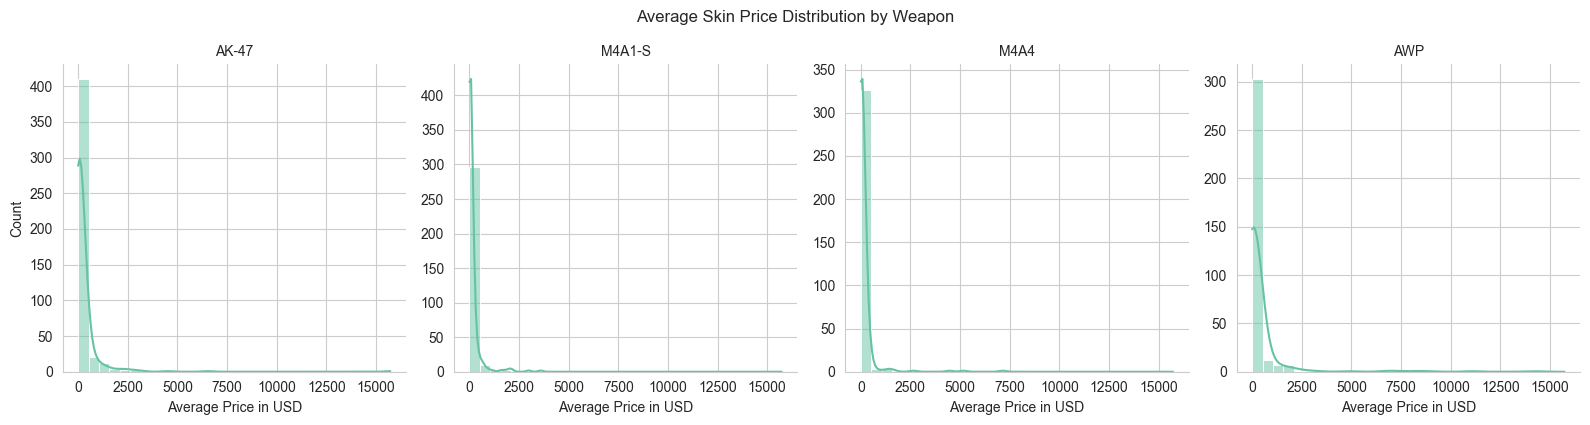

weapon
AK-47     12.04
AWP        6.89
M4A1-S     5.77
M4A4       8.93
Name: avg, dtype: float64

In [83]:
# Keep only the 4 weapon categories
weapon_order = ["AK-47", "M4A1-S", "M4A4", "AWP"]
df_weapons = df[df["weapon"].isin(weapon_order)].copy()

# Make sure avg is numeric
df_weapons["avg"] = pd.to_numeric(df_weapons["avg"], errors="coerce")

# Remove missing avg values
df_weapons = df_weapons.dropna(subset=["avg"])

# Raw histogram by weapon
g = sns.displot(
    data=df_weapons,
    x="avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("Average Price in USD", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Average Skin Price Distribution by Weapon", y=1.05)

plt.show()
df_weapons.groupby("weapon")["avg"].skew().round(2)

---

Here we can see that the raw histogram shows that average skin prices are highly right-skewed, where majority of skin are concentrated around lower price points. This makes sense, as Counter Strike's skin market is notoriously known for its high weapon skin prices, like the AWP Dragon Lore, being priced around $11,000. For our purposes of visualizing the data, we can appply a log transformation to `'avg'`

---

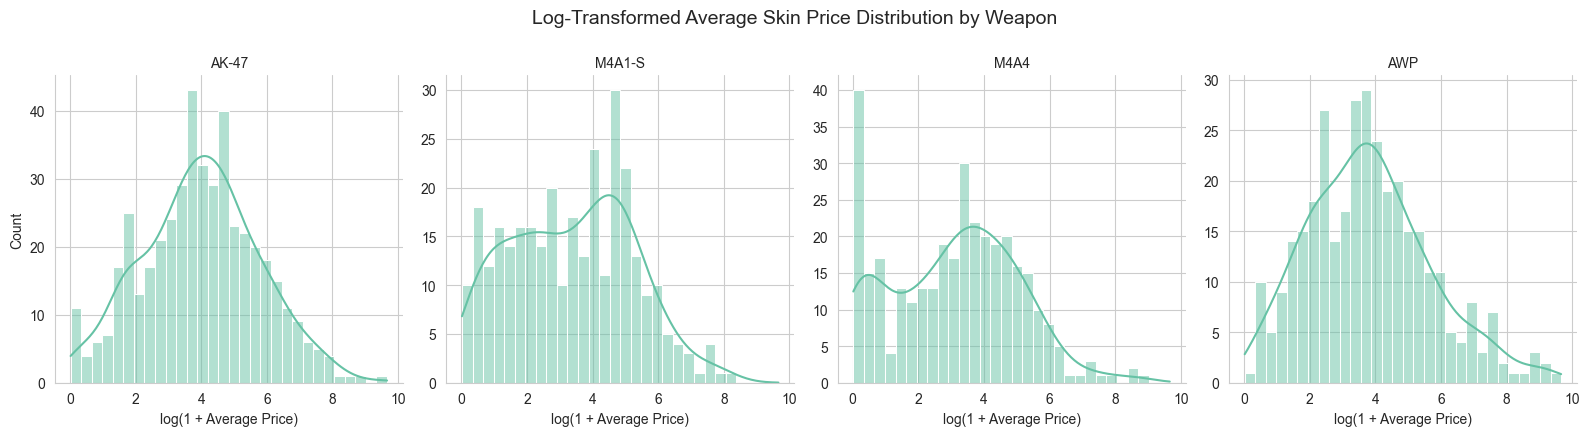

In [84]:
# Create log-transformed avg column
df_weapons["log_avg"] = np.log1p(df_weapons["avg"])

# log_avg histogram
g = sns.displot(
    data=df_weapons,
    x="log_avg",
    col="weapon",
    col_order=weapon_order,
    bins=30,
    kde=True,
    height=4,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels("log(1 + Average Price)", "Count")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Log-Transformed Average Skin Price Distribution by Weapon",
    y=1.08,
    fontsize=14
)

plt.show()

---

We can see that there is kind of an interesting pattern. For context, the game is separated into two teams; Terrorist (T) and Counter-Terrorist (CT), with the AK-47, M4A1-S, M4A4, and the AWP being "primary" weapons. There is nuance, in the fact that there are other weapons within the game, but for the majority of players, these weapons define the game.

What is interesting is the price distributions for the M4A1-S and M4A4. The M4A1-S and M4A4 are CT sided weapons only, where the restriction is that they do not have the ability to one shot an opponent. Contrary to the AK47, which is the only primary weapon for the T side. The AWP is its own separate "rifle" in the manner that it is a sniper rifle, but can be equipped on both sides.

The distributions for the average AK-47 and AWP prices follow an approximate bell curve. In contrast, the M4A1-S and the M4A4 show more tendencies to sell at lower-price points.

These trends could probably be explained by the fact that the AK-47 being the only "primary" weapon for the T side. While the M4A1-S and M4A4 are two options CT players can choose from, where both weapons are of equal popularity, selling them might be more difficult. The AWP can be explained as it is the only sniper rifle in the game that can one-shot enemy opponents.

---

## 2.2 Boxplots

---

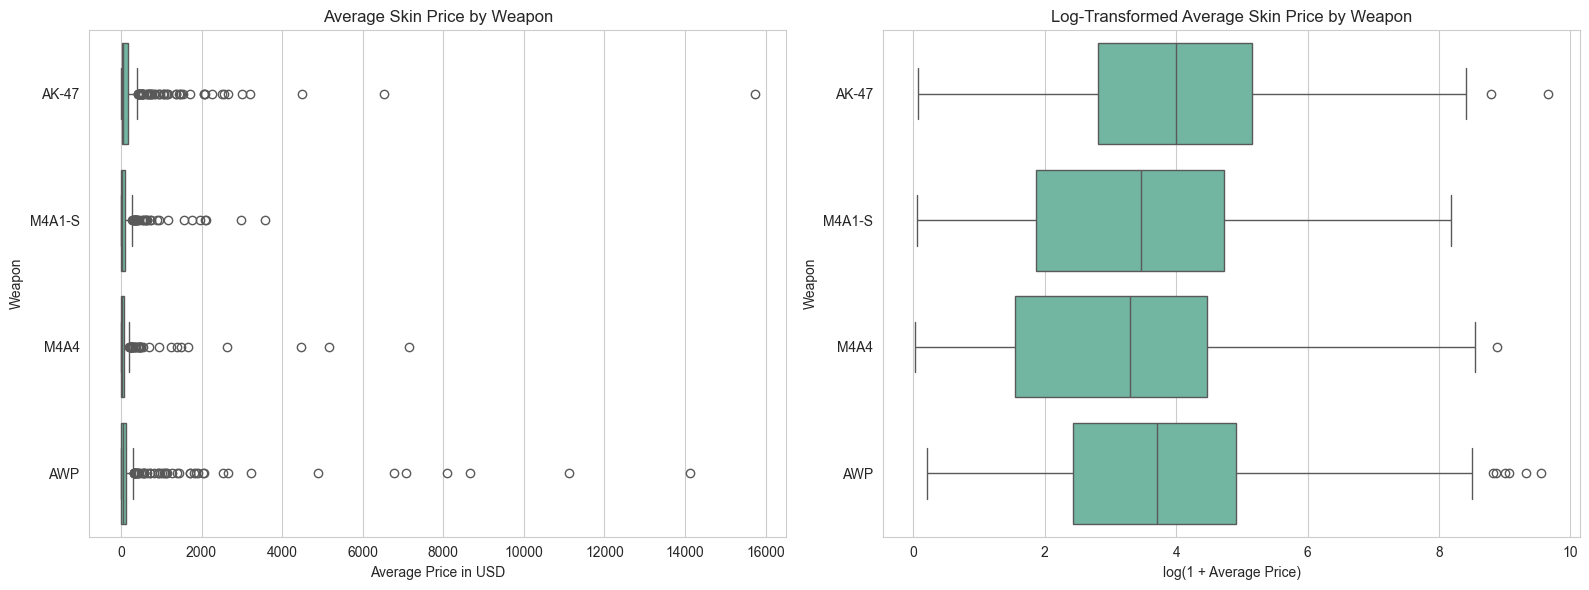

In [85]:
# Side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw average price
sns.boxplot(
    data=df_weapons,
    x="avg",
    y="weapon",
    order=weapon_order,
    ax=axes[0]
)

axes[0].set_title("Average Skin Price by Weapon")
axes[0].set_xlabel("Average Price in USD")
axes[0].set_ylabel("Weapon")

# Log-transformed average price
sns.boxplot(
    data=df_weapons,
    x="log_avg",
    y="weapon",
    order=weapon_order,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Average Skin Price by Weapon")
axes[1].set_xlabel("log(1 + Average Price)")
axes[1].set_ylabel("Weapon")

plt.tight_layout()
plt.show()


With the boxplots, we are able to look visualize the the weapon skin outliers. Here we can see that the AWP has the most average price outliers. The maximum value out of all the weapon seems to be for the AK-47. However, since Skinport is a community based market, it could just be a seller over-valuing their item.

---

## Summary statistics

---

In [86]:
# quick overview of numeric variables

df[['min', 'max', 'avg', 'median', 'volume']].describe().round(2)

,min,max,avg,median,volume
count,1445.00,1445.00,1445.00,1445.00,1445.00
mean,206.92,272.99,228.27,225.25,40.81
std,868.98,932.84,895.29,894.40,72.11
min,0.02,0.03,0.02,0.02,1.00
25%,5.86,13.92,8.19,7.79,4.00
50%,29.78,56.11,37.49,35.93,13.00
75%,102.64,181.07,126.03,119.76,44.00
max,15726.81,15726.81,15726.81,15726.81,768.00


## Average price by condition

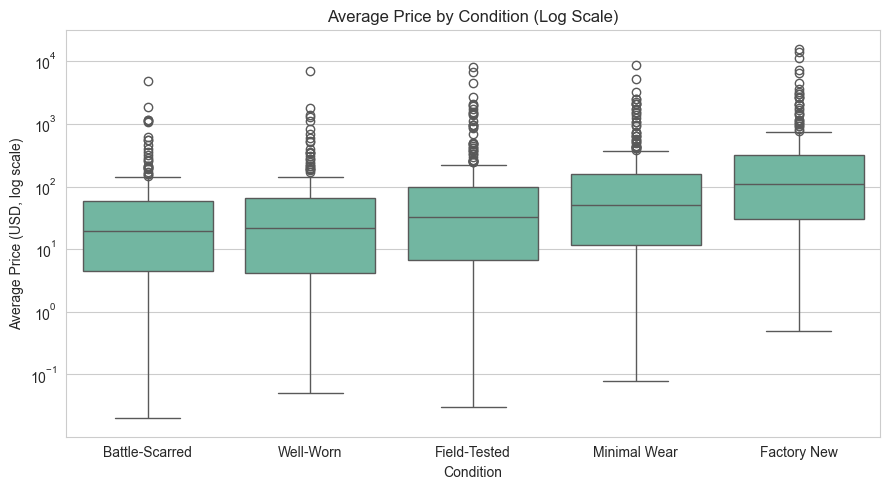

In [87]:
condition_labels = {
    0: 'Battle-Scarred', 
    1: 'Well-Worn', 
    2: 'Field-Tested', 
    3: 'Minimal Wear', 
    4: 'Factory New'
}

df['condition_label'] = df['condition'].map(condition_labels)
df = df.dropna(subset=['condition_label'])
cond_order = ['Battle-Scarred', 'Well-Worn', 'Field-Tested', 'Minimal Wear', 'Factory New']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='condition_label', y='avg', order=cond_order, ax=ax)
ax.set_yscale('log')
ax.set_title('Average Price by Condition (Log Scale)')
ax.set_xlabel('Condition')
ax.set_ylabel('Average Price (USD, log scale)')
plt.tight_layout()
plt.show()

## Price Premium: StatTrak™ and Souvenir

StatTrak™ skins track kill counts and typically sell at a premium. Souvenir skins are tournament drops and tend to have different pricing dynamics. We compare median average prices across these categories.

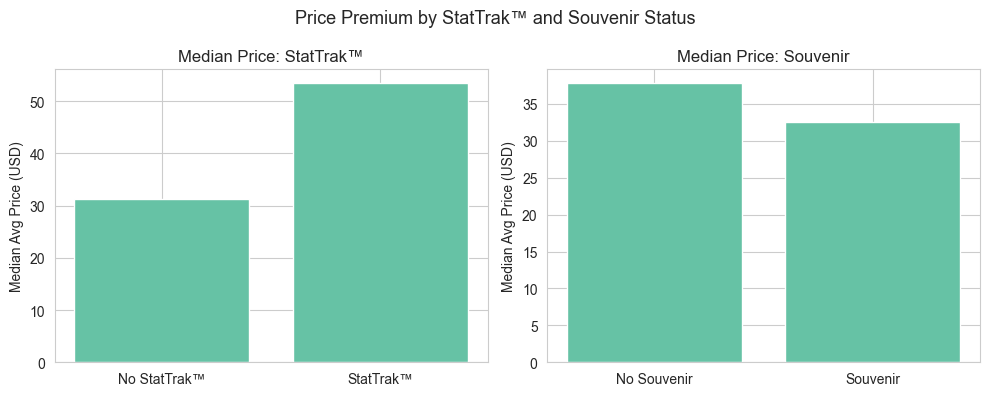

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['stat_trak', 'souvenir'], ['StatTrak™', 'Souvenir']):
    medians = df.groupby(col)['avg'].median()
    ax.bar([f'No {label}', label], [medians.get(0, 0), medians.get(1, 0)])
    ax.set_title(f'Median Price: {label}')
    ax.set_ylabel('Median Avg Price (USD)')

plt.suptitle('Price Premium by StatTrak™ and Souvenir Status', fontsize=13)
plt.tight_layout()
plt.show()

## Sales Volume by Weapon

Sales volume reflects market liquidity. Higher volume indicates more actively traded skins.

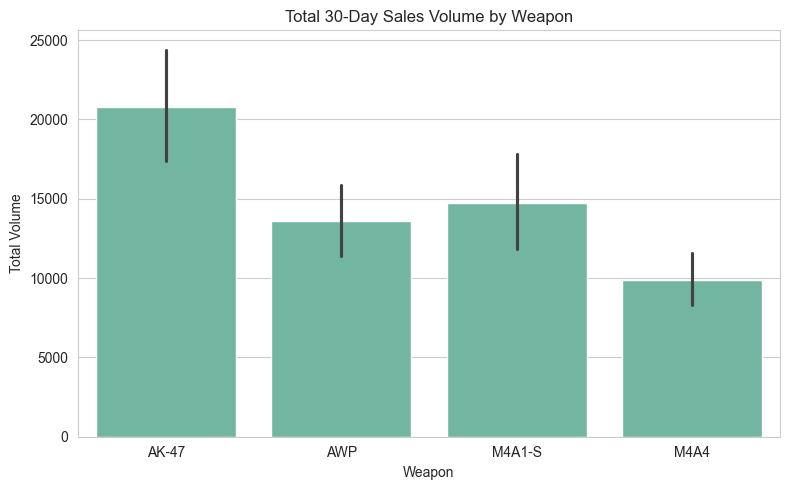

In [89]:
weapon_order = df.groupby('weapon')['avg'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='weapon', y='volume', order=weapon_order,
            estimator='sum', ax=ax)
ax.set_title('Total 30-Day Sales Volume by Weapon')
ax.set_xlabel('Weapon')
ax.set_ylabel('Total Volume')
plt.tight_layout()
plt.show()

## Correlation Heatmap

We examine pairwise correlations among numeric variables. Strong correlation between `min`, `max`, `avg`, and `median` is expected. The relationship between `condition` and price is of primary interest.

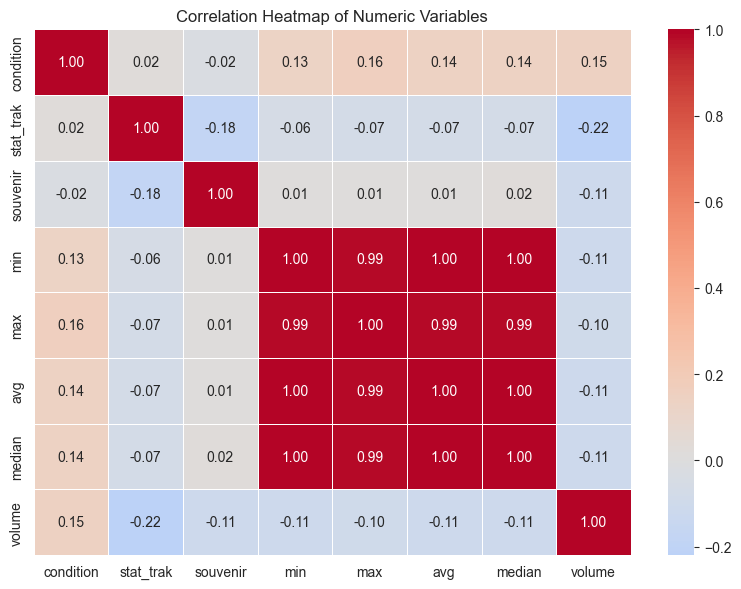

In [90]:
numeric_cols = ['condition', 'stat_trak', 'souvenir', 'min', 'max', 'avg', 'median', 'volume']
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

## Top 10 Most Expensive Skins

We identify the ten skins with the highest median average price over the past 30 days.

In [91]:
top10 = (
    df.groupby(['weapon', 'skin_name'])['avg']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Weapon', 'Skin', 'Median Avg Price (USD)']
top10['Median Avg Price (USD)'] = top10['Median Avg Price (USD)'].round(2)
top10

,Weapon,Skin,Median Avg Price (USD)
0,AK-47,Wild Lotus,15726.81
1,AWP,Gungnir,8099.76
2,AWP,Dragon Lore,7729.65
3,M4A4,Howl,5172.45
4,M4A1-S,Knight,2984.14
5,AWP,The Prince,2627.38
6,AK-47,Hydroponic,2083.46
7,M4A1-S,Hot Rod,2026.25
8,AWP,Medusa,1885.20
9,M4A1-S,Imminent Danger,1767.19


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats

sns.set_style('whitegrid')
sns.set_palette('Set2')

# Load cleaned data
df = pd.read_csv('data/skinport_items_cleaned(1).csv')

# Filter to the 4 weapons used in analysis
weapon_order = ['AK-47', 'M4A1-S', 'M4A4', 'AWP']
df_weapons = df[df['weapon'].isin(weapon_order)].copy()
df_weapons['avg'] = pd.to_numeric(df_weapons['avg'], errors='coerce')
df_weapons = df_weapons.dropna(subset=['avg'])

# Log-transform skewed variables
df_weapons['log_avg']    = np.log(df_weapons['avg'])
df_weapons['log_volume'] = np.log(df_weapons['volume'])

# 3. Baseline Multiple Linear Regression (MLR)
Before diving into other methods beyond OLS, we establish a baseline. Using `statsmodels`, we fit an unconstrained Multiple Linear Regression to predict average price based on these predictor variables: `condition`, `souvenir`, `stat_trak`. The summary statistics from this model will reveal our baseline $R^2$ and $p$-values, setting a floor for predictive performance and highlighting any immediate structural issues in the data.

In [108]:
import statsmodels.formula.api as smf

# Rename column 'avg' to avoid any python keyword conflicts if needed
# and clean up column names if they have trailing whitespaces
df.columns = [c.strip() for c in df.columns]

# Fit the Multiple Linear Regression model
# 'C(condition)' treats condition as a categorical factor variable 
# instead of a continuous variable, which it might want to due to the int type
mlr_formula = "avg ~ C(condition) + souvenir + stat_trak"
mlr_model = smf.ols(formula=mlr_formula, data=df).fit()

# print model summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    avg   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     7.224
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.30e-07
Time:                        00:19:42   Log-Likelihood:                -11850.
No. Observations:                1445   AIC:                         2.371e+04
Df Residuals:                    1438   BIC:                         2.375e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           132.8865     59.39

The MLR summary statistics reveal a severely poor fit with an $R^2$ hovering near zero (about 0.029, or only accounting for 2.9% of the variance in the data) and an extreme positive skew. To visualize exactly why the linear line is failing, we plot the predicted versus actual prices. The resulting scatter plot should demonstrate how vulnerable an unpenalized OLS model is to massive luxury asset outliers, and the ultimate poor validity of our model without using skin as a predictor.

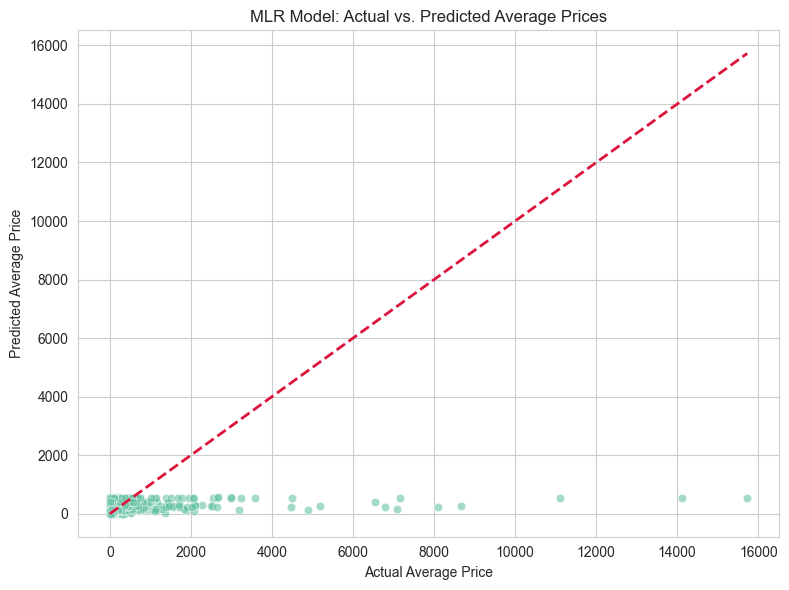

In [109]:
# Generate predictions
df['predicted_avg'] = mlr_model.predict(df)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='avg', y='predicted_avg', alpha=0.6)

# Plot a 45-degree line representing perfect prediction
max_val = max(df['avg'].max(), df['predicted_avg'].max())
min_val = min(df['avg'].min(), df['predicted_avg'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', lw=2, linestyle='--')

plt.title('MLR Model: Actual vs. Predicted Average Prices')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.tight_layout()
plt.show()

---
## 3.1 Multiple Linear Regression (MLR) Model 

We build a Multiple Linear Regression model to predict CS2 skin prices from their attributes. Because `avg` is highly right-skewed (as seen in the histograms above), we apply a **log transformation** to stabilize variance and satisfy MLR's homoscedasticity assumption. Similarly, `volume` is log-transformed since sales activity follows a multiplicative pattern.

The response variable is:
$$\log(\text{avg\_price}) = \beta_0 + \beta_1\,\text{condition} + \beta_2\,\text{souvenir} + \beta_3\,\mathbf{1}_{\text{AWP}} + \beta_4\,\mathbf{1}_{\text{M4A1-S}} + \beta_5\,\mathbf{1}_{\text{M4A4}} + \beta_6\,\log(\text{volume}) + \varepsilon$$

*(AK-47 is the reference weapon category)*

---
### 3.2 Model Comparison

We fit three nested models of increasing complexity and compare them using **Adjusted R²**, **AIC**, and **BIC**.  
Lower AIC/BIC indicates a better balance of fit vs. complexity. `stat_trak` was tested but dropped — it was not statistically significant (p = 0.57).

In [110]:
m1 = smf.ols('log_avg ~ condition',                                          data=df_weapons).fit()
m2 = smf.ols('log_avg ~ condition + souvenir + stat_trak',                   data=df_weapons).fit()
m3 = smf.ols('log_avg ~ condition + souvenir + C(weapon) + log_volume',      data=df_weapons).fit()

rows = []
for name, m in [
    ('M1: condition only',                m1),
    ('M2: + souvenir + stat_trak',        m2),
    ('M3: + weapon + log_volume (best OLS)', m3),
]:
    rows.append({
        'Model':    name,
        'k':        int(m.df_model) + 2,
        'R²':       round(m.rsquared, 4),
        'Adj. R²':  round(m.rsquared_adj, 4),
        'AIC':      round(m.aic, 1),
        'BIC':      round(m.bic, 1),
    })

pd.DataFrame(rows)


,Model,k,R²,Adj. R²,AIC,BIC
0,M1: condition only,3,0.0873,0.0867,6284.4,6295.0
1,M2: + souvenir + stat_trak,5,0.1032,0.1014,6263.1,6284.2
2,M3: + weapon + log_volume (best OLS),8,0.3110,0.3081,5888.2,5925.1


---
### 3.3 Best OLS Model Summary

M3 achieves the lowest AIC and BIC and the highest Adjusted R² among the OLS specifications. We therefore use it as our best OLS benchmark before moving to regularized models.

In [94]:
print(m3.summary())


                            OLS Regression Results                            
Dep. Variable:                log_avg   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     108.2
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          1.20e-112
Time:                        23:59:14   Log-Likelihood:                -2937.1
No. Observations:                1445   AIC:                             5888.
Df Residuals:                    1438   BIC:                             5925.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.1968    

---
### 3.4 Coefficient Interpretation

Because the response is log-transformed, coefficients are interpreted on a **multiplicative scale**: a coefficient $\hat{\beta}$ means the predicted price is multiplied by $e^{\hat{\beta}}$ for a one-unit increase in that predictor, holding all others constant.

| Predictor | Coef | $e^{\hat{\beta}}$ | Interpretation |
|---|---|---|---|
| Condition (+1 tier) | +0.661 | ×1.94 | Each wear tier roughly doubles the price |
| Souvenir | −0.393 | ×0.68 | Souvenir skins are ~32% cheaper on average |
| AWP vs AK-47 | −0.210 | ×0.81 | AWP skins slightly cheaper than AK-47 |
| M4A1-S vs AK-47 | −0.692 | ×0.50 | M4A1-S skins ~50% cheaper than AK-47 |
| M4A4 vs AK-47 | −1.372 | ×0.25 | M4A4 skins ~75% cheaper than AK-47 |
| log(volume) (+1%) | −0.633 | ×0.53 | Higher-volume (common) skins are cheaper |


---
### 3.5 Diagnostic Plots

We verify the four standard MLR assumptions:
1. **Residuals vs. Fitted** — linearity and homoscedasticity
2. **Normal Q-Q** — normality of residuals
3. **Scale-Location** — constant residual spread
4. **Residuals vs. Leverage** — influential observations

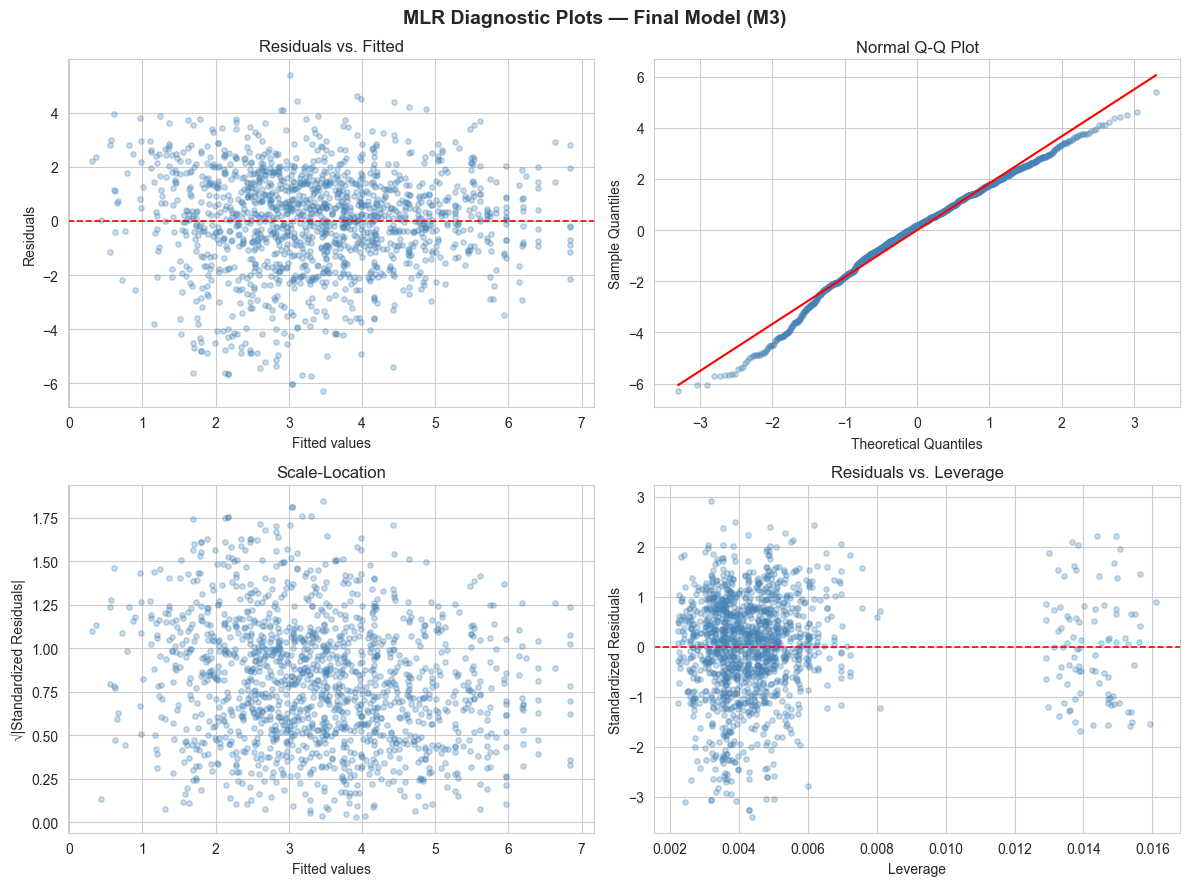

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('MLR Diagnostic Plots — Final Model (M3)', fontsize=14, fontweight='bold')

fitted    = m3.fittedvalues
resid     = m3.resid
std_resid = resid / resid.std()

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted, resid, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted')

# 2. Q-Q Plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
ax.scatter(osm, osr, alpha=0.3, s=15, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q-Q Plot')

# 3. Scale-Location
ax = axes[1, 0]
ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=15, color='steelblue')
ax.set_xlabel('Fitted values'); ax.set_ylabel('√|Standardized Residuals|')
ax.set_title('Scale-Location')

# 4. Residuals vs Leverage
leverage = m3.get_influence().hat_matrix_diag
ax = axes[1, 1]
ax.scatter(leverage, std_resid, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_xlabel('Leverage'); ax.set_ylabel('Standardized Residuals')
ax.set_title('Residuals vs. Leverage')

plt.tight_layout()
plt.show()


---
### 3.6 Model Limitations

- **R² = 0.31** — condition, weapon type, and volume explain about 31% of log-price variance. The remaining variance likely reflects **skin rarity and visual desirability**, which are not available in the Skinport API.
- The Q-Q plot shows mild **heavy tails**, meaning residuals are slightly non-normal — a small number of ultra-rare skins (e.g., AK-47 Fire Serpent) produce large outliers the model cannot fully account for.
- **Souvenir** (p = 0.056) is borderline significant and may not hold in every subsample.
- The model covers only 4 weapons; generalization to other weapon classes would require additional data.


# 4. Preparing for Lasso (L1 Regularization)
As expected, the baseline OLS predictions completely failed to capture the price variance, visually collapsing against the massive right-skew. 

To build a more resilient pricing model, we expand our feature matrix to include `weapon` and `volume`. However, adding more dimensions risks overfitting standard OLS. To prevent this, we transition to `Lasso Regression.` By applying an $L_1$ penalty, Lasso performs automatic variable selection. It mathematically shrinks the coefficients of irrelevant features exactly to zero. This ensures our final model remains sparse, interpretable, and driven only by true pricing signals. We dummy encode the categoricals and execute a standard 75/25 train-test split to evaluate this out-of-sample performance accurately.

In [98]:
from sklearn.model_selection import train_test_split

# Drop columns that have direct data leakage with average price (min, max, median) as we only care about average
# include weapon and volume to let Lasso perform selection
X = pd.get_dummies(df[['weapon', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                   columns=['weapon', 'condition'], drop_first=True)
y = df['avg']

# Split the data into 75% training and 25% testing, as is standard
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")

Training set: 1083 observations
Test set: 362 observations


Penalized regression algorithms apply a shrinkage penalty based on coefficient magnitude. Because our features exist on different mathematical scales (e.g., continuous volume vs. binary dummy variables), we must standardize the training data to a mean of zero and unit variance. This ensures the $L_1$ penalty is applied fairly across all predictors.

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

With our data properly scaled, we test three configurations: an unpenalized OLS baseline, a fixed Lasso model ($\alpha = 1$), and a cross-validated Lasso model (`LassoCV`) from sklearn that searches over a logarithmic grid to find the optimal $\lambda$ penalty. This allows us to observe how deliberately introducing a little bias through the $L_1$ constraint helps manage variance.

In [100]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

# 1. OLS baseline
ols_model = LinearRegression().fit(X_train_scaled, y_train)

# 2. fixed lasso where alpha = 1
lasso_fixed = Lasso(alpha=1, max_iter=10000, random_state=42)
lasso_fixed.fit(X_train_scaled, y_train)

# 3. CV Tuned Lasso (Searching over an alpha grid using 10-fold CV)
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=10, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Lasso optimal λ (alpha) selected via CV: {lasso_cv.alpha_:.4f}")

Lasso optimal λ (alpha) selected via CV: 2.1544


Having fit all three models, we compare their out-of-sample Mean Squared Error (MSE) and the total number of retained features. We expect the CV-tuned Lasso to minimize the out-of-sample error while performing automatic variable selection by shrinking irrelevant coefficients exactly to zero.

In [101]:
models = {
    'OLS Baseline': ols_model,
    'Lasso (alpha=1)': lasso_fixed,
    'Lasso (CV-Tuned)': lasso_cv
}

print(f"{'Method':<20} {'Test MSE':>15} {'# Features Retained':>22}")
print("----------------------------------------------------------------------")
for name, mdl in models.items():
    y_pred = mdl.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    n_features = (mdl.coef_ != 0).sum()
    print(f"{name:<20} {mse:>15.2f} {n_features:>22}")

Method                      Test MSE    # Features Retained
----------------------------------------------------------------------
OLS Baseline               240020.20                     10
Lasso (alpha=1)            239270.82                     10
Lasso (CV-Tuned)           238489.40                      9


The comparison confirms the CV-tuned Lasso successfully dropped noise variables while marginally improving error metrics. To understand the geometry of this variable selection, we trace the coefficient path across a spectrum of $\lambda$ values. This plot visually demonstrates how the $L_1$ constraint forces coefficients to the zero axis as the penalty intensifies, marking our optimal cross-validated $\lambda$. 

Still note that the MSE is incredibly high due to the right skewed outliers. This will motivate our final model. 

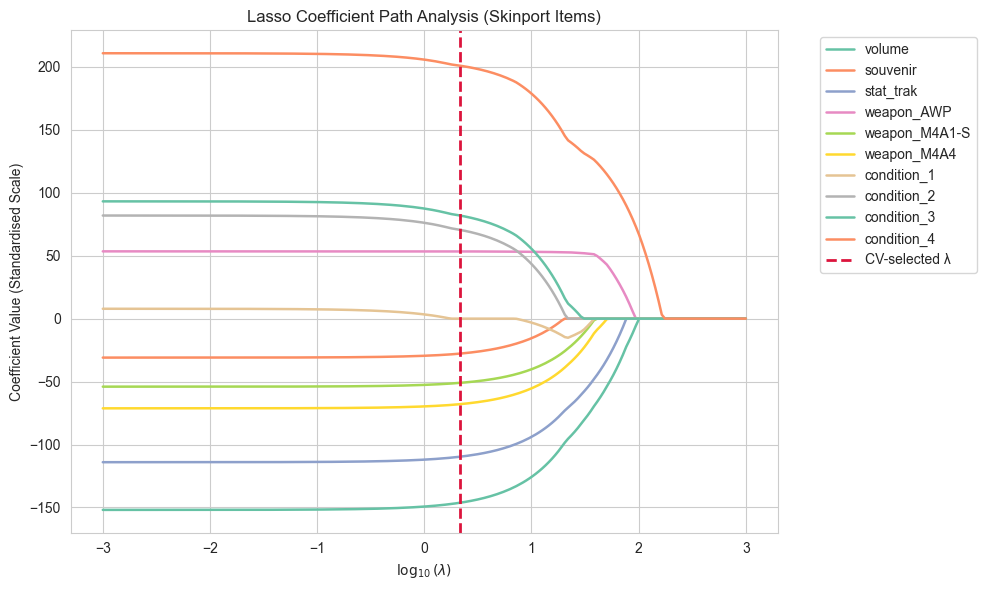

In [102]:
alphas = np.logspace(-3, 3, 200)
coef_paths = np.array([Lasso(alpha=a, max_iter=10000, random_state=42).fit(X_train_scaled, y_train).coef_ for a in alphas])

plt.figure(figsize=(10, 6))
for j, feature_name in enumerate(X.columns):
    plt.plot(np.log10(alphas), coef_paths[:, j], label=feature_name, lw=1.8)

plt.axvline(np.log10(lasso_cv.alpha_), color='crimson', linestyle='--', lw=2, label='CV-selected λ')
plt.title('Lasso Coefficient Path Analysis (Skinport Items)')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Coefficient Value (Standardised Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('lasso_coefficient_path.png')
plt.show()

## 5. The Final Model via Log Transformation
While the regularized model reduced variance, the absolute error remains high due to the extreme right-tail pricing outliers. To fix this, we build the V2 Model, using the log of price. 

First, we apply a log-transform to the target variable (`avg`) to compress the tail, shifting our predictions from additive dollar amounts to multiplicative percentage changes. Crucially, we also explode the feature space by including the specific `skin_name`. This eliminates the omitted variable bias that crippled our baseline models. We will rely on Lasso's $L_1$ penalty to prevent this high-dimensional space from overfitting.

Note that we could NEVER do this in OLS, as there are over 200 invidual skin names, so the categorical variable would be massively overfit as there only averages around 4 samples per skin. 

In [103]:
# 1. log transform the dependent variable
# We use log1p (log(1 + x)) to safely handle any values very close to 0
y_log = np.log1p(df['avg'])

# 2. 3xpand the Feature Space to include the actual skin finishes, which we couldn't have before
X_expanded = pd.get_dummies(df[['weapon', 'skin_name', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                            columns=['weapon', 'skin_name', 'condition'], drop_first=True)

# 3. train / test split using the new matrices
X_train_exp, X_test_exp, y_train_log, y_test_log = train_test_split(X_expanded, y_log, test_size=0.25, random_state=42)

# 4.standardize the expanded feature set
scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# 5. fit the new CV-Tuned Lasso Model
# we increase max_iter because the expanded feature space takes longer to converge
lasso_cv_v2 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=10, max_iter=50000, random_state=42)
lasso_cv_v2.fit(X_train_exp_scaled, y_train_log)

# 6. Evaluate Performance on the original dollar scale
# We must use expm1 (exponential minus 1) to reverse the log1p transform for our predictions
y_pred_log = lasso_cv_v2.predict(X_test_exp_scaled)
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_log)

v2_mse = mean_squared_error(y_test_dollars, y_pred_dollars)
n_features_v2 = (lasso_cv_v2.coef_ != 0).sum()

print(f"V2 Lasso optimal λ: {lasso_cv_v2.alpha_:.5f}")
print(f"V2 Test MSE (in dollars squared): {v2_mse:.2f}")
print(f"V2 Test RMSE (in dollars): ${np.sqrt(v2_mse):.2f}")
print(f"Features Retained: {n_features_v2} / {X_expanded.shape[1]}")

V2 Lasso optimal λ: 0.00413
V2 Test MSE (in dollars squared): 48092.16
V2 Test RMSE (in dollars): $219.30
Features Retained: 193 / 201


The V2 model represents a massive leap in accuracy, dropping the RMSE significantly to around 200 dollars while retaining the vast majority of our new skin-specific features. 

Because we predicted the log of the price, these coefficients represent exponential scaling factors. Here, we extract the non-zero coefficients and mathematically convert them into percentage markups. This allows us to isolate the specific visual assets and conditions that drive the highest market premiums.

In [104]:
# Create a dataframe of the features and their coefficients
coef_df = pd.DataFrame({
    'Feature': X_expanded.columns,
    'Log_Coefficient': lasso_cv_v2.coef_
})

# filter out coefficients that lasso zeroed out
coef_df = coef_df[coef_df['Log_Coefficient'] != 0]

# Calculate the actual percentage multiplier
# Formula: (e^beta - 1) * 100
coef_df['Percentage_Markup'] = (np.exp(coef_df['Log_Coefficient']) - 1) * 100

# Sort by the highest positive impact
coef_df_sorted = coef_df.sort_values(by='Log_Coefficient', ascending=False)

print("Top 10 Value-Adding Features ")
print(coef_df_sorted.head(10).to_string(index=False))

print("\nBottom 5 Value-Decreasing Features")
print(coef_df_sorted.tail(5).to_string(index=False))

Top 10 Value-Adding Features 
                Feature  Log_Coefficient  Percentage_Markup
            condition_4         0.615923          85.136470
skin_name_Case Hardened         0.407824          50.354249
  skin_name_Dragon Lore         0.338717          40.314579
 skin_name_Desert Hydra         0.313119          36.768484
 skin_name_Fire Serpent         0.310428          36.400922
      skin_name_Gungnir         0.305383          35.714536
            condition_3         0.304074          35.536976
       skin_name_Medusa         0.245110          27.776134
  skin_name_Printstream         0.235959          26.612263
      skin_name_Asiimov         0.230640          25.940555

Bottom 5 Value-Decreasing Features
              Feature  Log_Coefficient  Percentage_Markup
   skin_name_Mud-Spec        -0.210303         -18.966154
     skin_name_Choppa        -0.228613         -20.436383
   skin_name_Poly Mag        -0.229264         -20.488173
  skin_name_Mainframe        -0.234473    

Our extracted coefficients correctly identified legendary tier assets (like the Dragon Lore and Case Hardened) as massive value multipliers, and proved that a Factory New condition acts as a scaling percentage markup. On average, a factory new skin demands an 85% premium over holding every other variable constant, except if it was battle scarred!

To confirm the structural health of this V2 model, we plot the predicted vs. actual values on the log scale, alongside a residuals plot. We are looking for a tight fit along the 45-degree line and a balanced residual cloud, indicating we've successfully stripped away the skewness bias.

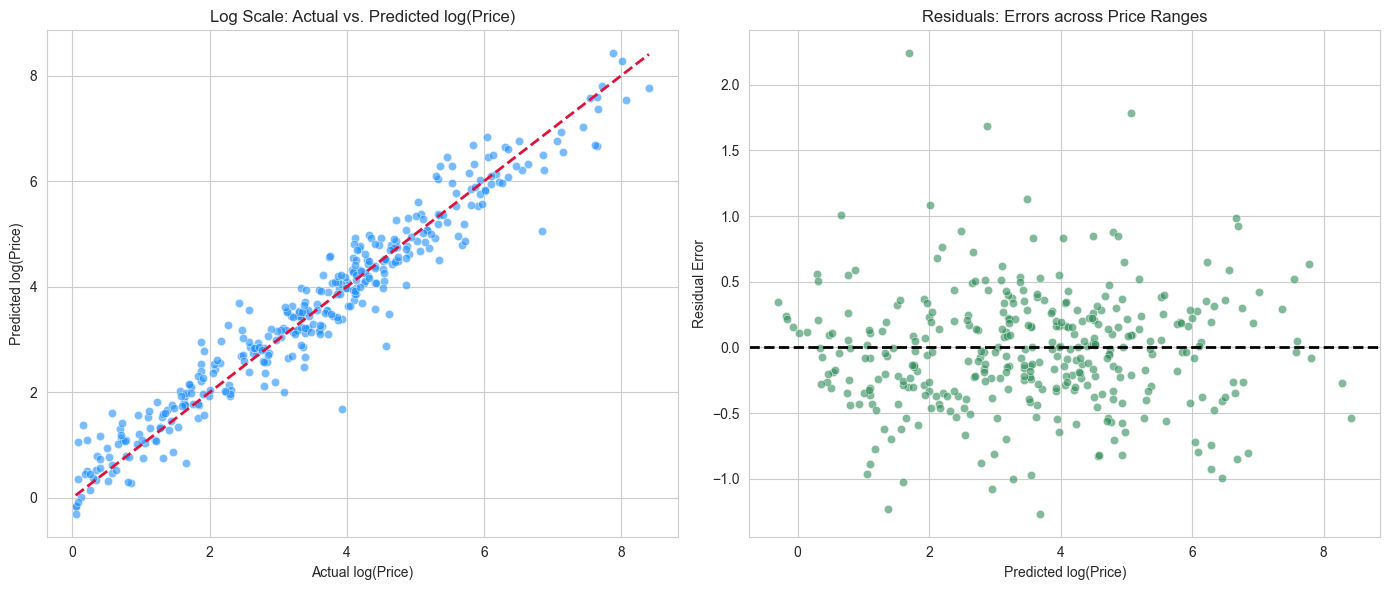

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted on Log Scale, which is how the model sees it
sns.scatterplot(x=y_test_log, y=y_pred_log, alpha=0.6, ax=axes[0], color='dodgerblue')
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 
             color='crimson', lw=2, linestyle='--')
axes[0].set_title('Log Scale: Actual vs. Predicted log(Price)')
axes[0].set_xlabel('Actual log(Price)')
axes[0].set_ylabel('Predicted log(Price)')

# Plot 2: Residuals Plot (Checking for bias, want a random scatter around 0 with no patterns)
residuals_log = y_test_log - y_pred_log
sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.6, ax=axes[1], color='seagreen')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_title('Residuals: Errors across Price Ranges')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual Error')

plt.tight_layout()
plt.show()

## 6. Using the Model to Find Market Inefficiencies
The diagnostic plots confirm a healthy, proportional fit across the pricing spectrum. 

As a final step, we transition from observation to a quantitative strategy. By generating predictions for the entire liquid market, we calculate the arbitrage spread (the difference between our modeled intrinsic value and the actual dataset average). Sorting these spreads yields our top buy (undervalued) and sell/short (overvalued) candidates, which can then be stress-tested against the live market order books for actual mispricings.

In [106]:
# 1. Generate predictions for the full dataset using your V2 model
X_full_exp_scaled = scaler_exp.transform(X_expanded)
full_predictions_log = lasso_cv_v2.predict(X_full_exp_scaled)

# 2. Reverse the log transform and add to the main dataframe
df['predicted_avg'] = np.expm1(full_predictions_log)

# 3. Calculate the Arbitrage Spread (Residuals)
# Positive Spread = Undervalued (Model > Actual) -> Buy Signal
# Negative Spread = Overvalued (Model < Actual) -> Sell Signal
df['arbitrage_spread'] = df['predicted_avg'] - df['avg']
df['spread_percentage'] = (df['arbitrage_spread'] / df['avg']) * 100

# 4. Filter for liquidity (e.g., must have traded at least 5 times)
liquid_df = df[df['volume'] >= 10].copy()

# 5. Extract the target lists
undervalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=False)
overvalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=True)

print("Top 10 most undervalued skins")
cols_to_show = ['weapon', 'skin_name', 'condition', 'avg', 'predicted_avg', 'arbitrage_spread', 'spread_percentage']
print(undervalued_picks[cols_to_show].head(10).to_string(index=False))

print("\n Top 10 most overvalued skins")
print(overvalued_picks[cols_to_show].head(10).to_string(index=False))

Top 10 most undervalued skins
weapon     skin_name  condition    avg  predicted_avg  arbitrage_spread  spread_percentage
 AK-47 Case Hardened          3 340.70     796.035591        455.335591         133.647077
  M4A4         X-Ray          4 210.72     533.940456        323.220456         153.388599
 AK-47 Case Hardened          2 253.60     534.156704        280.556704         110.629615
M4A1-S          Fade          4 376.10     637.131598        261.031598          69.404839
M4A1-S         Cyrex          4 198.89     440.422045        241.532045         121.440015
 AK-47    Bloodsport          4 423.79     635.155149        211.365149          49.874973
M4A1-S   Icarus Fell          4 657.58     863.372774        205.792774          31.295473
 AK-47        Vulcan          4 668.73     870.267047        201.537047          30.137282
 AK-47    Bloodsport          4 201.02     401.142436        200.122436          99.553495
 AK-47 Case Hardened          1 227.88     418.913798       

Taking a look at a random candidate, say the `M4A1-S Printstream` with condition = 2, which translates to `condition = field tested` on the counterstrike market. Since this data is about a week old, looking at the current market should tell us if this skin was 38% overvalued, as our model suggests (predicted average price 228, actual average 373). Looking at the market, we were able to find the following Printstream:



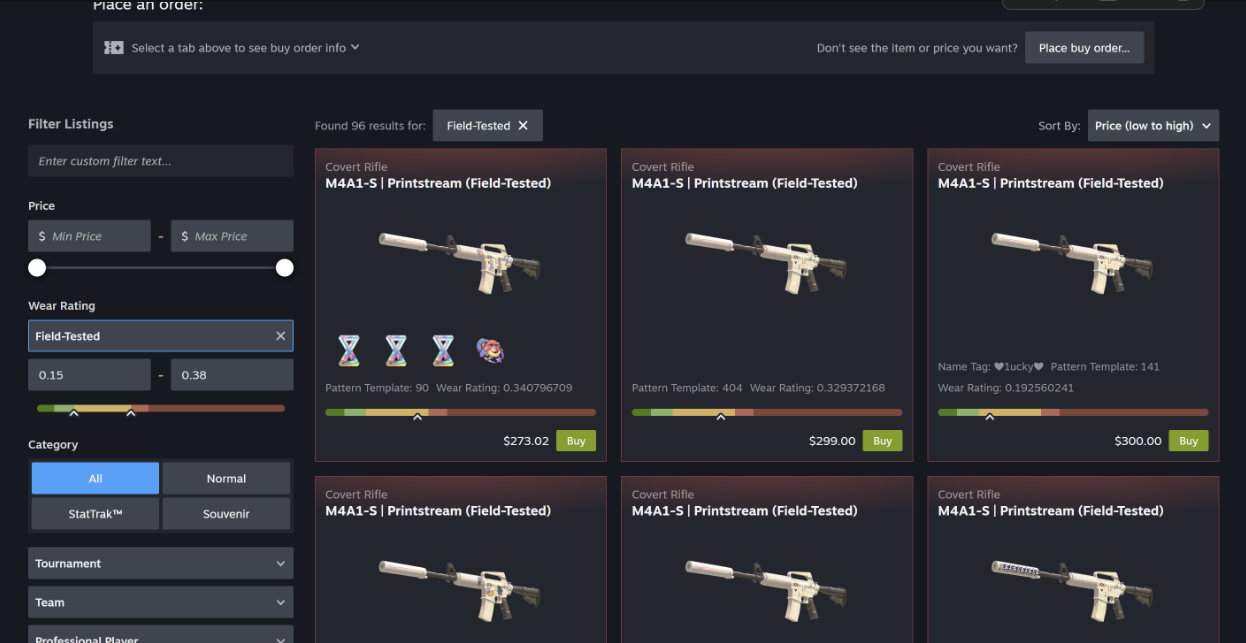

Nice! in just a week, the average went from around 373 to the high 300s range, indicating that our model was able to look past the noise of the market and correctly predict a fair value for this skin. 